# Phase 5 — Salary Modelling

We model UK data-role salaries two ways and compare them:

1. **Real (employer-posted) salaries** — figures published by the employer (`salary_is_predicted = False`).
2. **Adzuna-predicted salaries** — Adzuna's own model estimates (`salary_is_predicted = True`).

For each target we compare four models (baseline → Ridge → Random Forest → XGBoost) under
identical 5-fold cross-validation. **All preprocessing is fit inside each CV fold via a
scikit-learn `Pipeline`, so there is no train/test leakage.** The two questions are:
how well can posting features explain each kind of salary, and what drives each?

In [1]:
import pandas as pd
import numpy as np

# Load the clustered dataset from Phase 4
df = pd.read_parquet("../data/processed/postings_clustered.parquet")
print(f"Loaded: {len(df):,} postings")
print(f"  Real (employer-posted) salaries: {(~df['salary_is_predicted']).sum():,}")
print(f"  Adzuna-predicted salaries:       {df['salary_is_predicted'].sum():,}")
print(f"  Has cluster label:               {df['cluster_name'].notna().sum():,}")

Loaded: 2,835 postings
  Real (employer-posted) salaries: 1,012
  Adzuna-predicted salaries:       1,823
  Has cluster label:               2,835


## Feature engineering

Three feature groups feed the models:

- **Categorical** (one-hot): role-archetype cluster, region (top-15 + "Other"), Adzuna category, contract type, contract time.
- **Text** (TF-IDF): job-title text, 1–2 word n-grams, top 200 by frequency.
- **Numeric** (scaled): title word count, seniority/junior flags, description length, keywords matched.

The seniority flags use **non-capturing** groups `(?:...)` so pandas doesn't emit a match-group warning.
We build only the row-wise derived columns here; the TF-IDF / one-hot / scaling transforms are deferred
to the pipeline so they can be fit per-fold.

In [2]:
# --- Categorical: role cluster as string ---
feat = df.copy()
feat["cluster_str"] = feat["cluster"].astype(str)

# --- Location: take the region (second element of the area list), then keep top 15 ---
def extract_region(loc_area):
    if not isinstance(loc_area, (list, np.ndarray)):
        return "Unknown"
    if len(loc_area) >= 2:
        return loc_area[1]
    return loc_area[0] if len(loc_area) > 0 else "Unknown"

feat["region"] = feat["location_area"].apply(extract_region)
top_regions = feat["region"].value_counts().head(15).index.tolist()
feat["region_grouped"] = feat["region"].apply(lambda r: r if r in top_regions else "Other")

# --- Fill categorical nulls ---
feat["contract_type"] = feat["contract_type"].fillna("unknown")
feat["contract_time"] = feat["contract_time"].fillna("unknown")
feat["category_label"] = feat["category_label"].fillna("Unknown")

# --- Numeric / title-derived features (non-capturing regex groups) ---
feat["title_word_count"] = feat["title"].str.split().str.len()
feat["title_has_senior"] = feat["title"].str.lower().str.contains(
    r"\b(?:senior|lead|principal|head|director|manager|chief)\b", regex=True).astype(int)
feat["title_has_junior"] = feat["title"].str.lower().str.contains(
    r"\b(?:junior|graduate|trainee|apprentice|entry)\b", regex=True).astype(int)
feat["title"] = feat["title"].fillna("")

print("Senior-flagged:", int(feat['title_has_senior'].sum()),
      "| Junior-flagged:", int(feat['title_has_junior'].sum()))
print("Top regions:", top_regions[:5], "...")

Senior-flagged: 1057 | Junior-flagged: 91
Top regions: ['London', 'UK', 'North West England', 'South East England', 'South West England'] ...


## Outlier handling

A handful of salaries are data-entry errors or non-UK/freelance figures that would distort the model.
We remove obvious low errors (< £15K), winsorise extreme highs at £200K, and drop rows with no salary.

In [3]:
# Inspect the extremes before acting
low = feat[feat["salary_midpoint"] < 15000]
high = feat[feat["salary_midpoint"] > 200000]
print(f"Low outliers (<£15K): {len(low)} | High outliers (>£200K): {len(high)} | Missing: {feat['salary_midpoint'].isna().sum()}")

Low outliers (<£15K): 8 | High outliers (>£200K): 6 | Missing: 3


In [4]:
# Apply: drop low errors, cap highs at £200K, drop missing
before = len(feat)
feat = feat[~(feat["salary_midpoint"] < 15000)].copy()
feat.loc[feat["salary_midpoint"] > 200000, "salary_midpoint"] = 200000
feat = feat[feat["salary_midpoint"].notna()].copy()
print(f"Modelling dataset: {len(feat):,} rows (was {before:,})")
print(f"  Real: {(~feat['salary_is_predicted']).sum():,} | Predicted: {feat['salary_is_predicted'].sum():,}")

Modelling dataset: 2,824 rows (was 2,835)
  Real: 1,001 | Predicted: 1,823


## Leak-free model comparison

The key methodological point: **preprocessing lives inside the pipeline**. `ColumnTransformer`
fits the TF-IDF vocabulary/IDF, the one-hot categories, and the scaler statistics on each
training fold only — the validation fold never informs them. We pass the *raw* feature columns
to `cross_validate`; the pipeline transforms them fold-by-fold.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate, KFold
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

cat_features = ["cluster_str", "region_grouped", "contract_type", "contract_time", "category_label"]
num_features = ["title_word_count", "title_has_senior", "title_has_junior",
                "description_length", "n_keywords_matched"]
text_col = "title"

def make_preprocessor():
    # Fit fresh inside every fold -> no leakage
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("txt", TfidfVectorizer(max_features=200, ngram_range=(1, 2),
                                stop_words="english", min_df=5), text_col),
        ("num", StandardScaler(), num_features),
    ])

models = {
    "Baseline (predict mean)": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                            n_jobs=-1, random_state=42, verbosity=0),
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(subset, label):
    X = subset[cat_features + [text_col] + num_features]
    y = subset["salary_midpoint"].values
    rows = []
    print(f"\n=== {label} (n={len(y):,}) ===")
    for name, est in models.items():
        pipe = Pipeline([("prep", make_preprocessor()), ("model", est)])
        res = cross_validate(pipe, X, y, cv=cv,
                             scoring=["r2", "neg_mean_absolute_error"], n_jobs=1)
        r2 = res["test_r2"]; mae = -res["test_neg_mean_absolute_error"]
        rows.append({"model": name, "r2_mean": r2.mean(), "r2_std": r2.std(),
                     "mae_mean": mae.mean(), "mae_std": mae.std()})
        print(f"  {name:24s} R2={r2.mean():.3f}+/-{r2.std():.3f}  MAE=£{mae.mean():,.0f}")
    return pd.DataFrame(rows)

real = feat[~feat["salary_is_predicted"]]
pred = feat[feat["salary_is_predicted"]]
results_real = evaluate(real, "EMPLOYER-POSTED SALARIES")
results_pred = evaluate(pred, "ADZUNA-PREDICTED SALARIES")

results_real.to_csv("../data/processed/model_results_real.csv", index=False)
results_pred.to_csv("../data/processed/model_results_predicted.csv", index=False)
print("\nSaved model_results_real.csv and model_results_predicted.csv")


=== EMPLOYER-POSTED SALARIES (n=1,001) ===


  Baseline (predict mean)  R2=-0.011+/-0.011  MAE=£28,280
  Ridge Regression         R2=0.421+/-0.082  MAE=£20,078


  Random Forest            R2=0.481+/-0.051  MAE=£17,352


  XGBoost                  R2=0.503+/-0.085  MAE=£16,752

=== ADZUNA-PREDICTED SALARIES (n=1,823) ===
  Baseline (predict mean)  R2=-0.008+/-0.004  MAE=£13,039


  Ridge Regression         R2=0.365+/-0.058  MAE=£9,972


  Random Forest            R2=0.357+/-0.077  MAE=£9,969


  XGBoost                  R2=0.377+/-0.072  MAE=£9,608

Saved model_results_real.csv and model_results_predicted.csv


## Feature importance

We fit one XGBoost pipeline per target on all of that target's rows and read importances off the
fitted model, mapping them back to feature names from the fitted `ColumnTransformer`. With 200
TF-IDF features the individual importances are small and noisy, so we read them directionally.

In [6]:
def importance(subset):
    X = subset[cat_features + [text_col] + num_features]
    y = subset["salary_midpoint"].values
    pipe = Pipeline([("prep", make_preprocessor()),
                     ("model", XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                            n_jobs=-1, random_state=42, verbosity=0))])
    pipe.fit(X, y)
    prep = pipe.named_steps["prep"]
    names = (list(prep.named_transformers_["cat"].get_feature_names_out(cat_features))
             + list(prep.named_transformers_["txt"].get_feature_names_out())
             + num_features)
    return pd.DataFrame({"feature": names,
                         "importance": pipe.named_steps["model"].feature_importances_}
                        ).sort_values("importance", ascending=False)

imp_real = importance(real)
imp_pred = importance(pred)
imp_real.to_csv("../data/processed/feature_importance_real.csv", index=False)
imp_pred.to_csv("../data/processed/feature_importance_predicted.csv", index=False)

print("TOP 10 — real (employer-posted) salaries")
print(imp_real.head(10).to_string(index=False))
print("\nTOP 10 — Adzuna-predicted salaries")
print(imp_pred.head(10).to_string(index=False))

TOP 10 — real (employer-posted) salaries
              feature  importance
                   12    0.085735
region_grouped_London    0.039449
contract_time_unknown    0.038976
     title_has_senior    0.034715
              cleared    0.027925
              martech    0.026190
        analyst month    0.025629
     title_has_junior    0.023993
            scientist    0.023970
                month    0.023026

TOP 10 — Adzuna-predicted salaries
                     feature  importance
            title_has_senior    0.074030
            title_has_junior    0.040841
                     analyst    0.036545
                          vp    0.030247
                   president    0.029710
                      intern    0.027993
                        head    0.019313
category_label_Teaching Jobs    0.017973
              cluster_str_12    0.017723
                scientist ai    0.012099


## Summary

The numbers below are **derived from the results above**, not hardcoded, so they stay in sync if
the data is regenerated.

In [7]:
def row(dfr, m): return dfr.set_index("model").loc[m]
xr = row(results_real, "XGBoost"); xp = row(results_pred, "XGBoost")
br = row(results_real, "Baseline (predict mean)"); bp = row(results_pred, "Baseline (predict mean)")

def london_rank(imp):
    imp = imp.reset_index(drop=True)
    hit = imp.index[imp.feature == "region_grouped_London"].tolist()
    return (hit[0] + 1) if hit else None

print("XGBoost — real salaries:    R2 = {:.3f}, MAE = £{:,.0f}".format(xr.r2_mean, xr.mae_mean))
print("XGBoost — Adzuna predicted: R2 = {:.3f}, MAE = £{:,.0f}".format(xp.r2_mean, xp.mae_mean))
print("MAE improvement over baseline: real {:.0f}%, predicted {:.0f}%".format(
    (br.mae_mean - xr.mae_mean) / br.mae_mean * 100,
    (bp.mae_mean - xp.mae_mean) / bp.mae_mean * 100))
print("London feature rank — real: #{}  |  predicted: #{}".format(
    london_rank(imp_real), london_rank(imp_pred)))
print("\nReal salaries are MORE predictable than Adzuna's own predictions.")
print("London is a top-feature for real salaries but not for Adzuna's predictions —")
print("Adzuna's model appears to underweight UK location.")

XGBoost — real salaries:    R2 = 0.503, MAE = £16,752
XGBoost — Adzuna predicted: R2 = 0.377, MAE = £9,608
MAE improvement over baseline: real 41%, predicted 26%
London feature rank — real: #2  |  predicted: #39

Real salaries are MORE predictable than Adzuna's own predictions.
London is a top-feature for real salaries but not for Adzuna's predictions —
Adzuna's model appears to underweight UK location.


## Does a log-salary target help?

Salaries are right-skewed, which can hurt models that assume additive, symmetric errors.
We test a `log(salary)` target using `TransformedTargetRegressor` — it trains on `log(y)` and
**back-transforms predictions to £** so the R²/MAE below are directly comparable to the
linear-target models above. We compare the linear model (Ridge) and the boosted model (XGBoost)
on both targets.

In [14]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
import numpy as np

def compare_targets(subset, label):
    X = subset[cat_features + [text_col] + num_features]
    y = subset["salary_midpoint"].values
    rows = []
    for name, est in [("Ridge", Ridge(alpha=1.0)),
                      ("XGBoost", XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                                               n_jobs=-1, random_state=42, verbosity=0))]:
        # linear target
        lin = Pipeline([("prep", make_preprocessor()), ("model", est)])
        rl = cross_validate(lin, X, y, cv=cv, scoring=["r2", "neg_mean_absolute_error"], n_jobs=1)
        # log target (trained on log y, predictions back-transformed to £)
        log = TransformedTargetRegressor(
            regressor=Pipeline([("prep", make_preprocessor()), ("model", est)]),
            func=np.log, inverse_func=np.exp)
        rg = cross_validate(log, X, y, cv=cv, scoring=["r2", "neg_mean_absolute_error"], n_jobs=1)
        rows.append({"model": name, "target": "linear £",
                     "r2": rl["test_r2"].mean(), "mae": -rl["test_neg_mean_absolute_error"].mean()})
        rows.append({"model": name, "target": "log £",
                     "r2": rg["test_r2"].mean(), "mae": -rg["test_neg_mean_absolute_error"].mean()})
    out = pd.DataFrame(rows)
    print(f"=== {label} ===")
    for _, r in out.iterrows():
        print(f"  {r['model']:8s} {r['target']:9s}  R2={r['r2']:.3f}  MAE=£{r['mae']:,.0f}")
    return out

log_real = compare_targets(real, "REAL (employer-posted)")
log_pred = compare_targets(pred, "ADZUNA-PREDICTED")

=== REAL (employer-posted) ===
  Ridge    linear £   R2=0.421  MAE=£20,078
  Ridge    log £      R2=0.425  MAE=£19,129
  XGBoost  linear £   R2=0.503  MAE=£16,752
  XGBoost  log £      R2=0.505  MAE=£16,401
=== ADZUNA-PREDICTED ===
  Ridge    linear £   R2=0.365  MAE=£9,972
  Ridge    log £      R2=0.366  MAE=£9,850
  XGBoost  linear £   R2=0.377  MAE=£9,608
  XGBoost  log £      R2=0.376  MAE=£9,593


**Takeaway.** The log target gives a small but consistent **MAE** improvement, largest for the
linear model on real salaries (Ridge £20,078 → £19,129). XGBoost barely moves (£16,752 → £16,401)
because the tree model already handles the skew through its splits, and R² is essentially unchanged.
So: worth using a log target if you ship the linear model; not a game-changer for the boosted one.

## SHAP — what drives an individual salary prediction?

Gain-based importance tells us *which* features the model uses but not *how* or in *what direction*.
SHAP attributes each prediction back to its features in **£ terms**, so we can say e.g. "being in
London adds ~£9K on average." We compute exact TreeSHAP values via XGBoost's native `pred_contribs`
(robust across library versions) on the real-salary model and save a beeswarm + bar summary.

Model base value (mean prediction): £69,884

Top salary drivers by mean |SHAP| (average £ impact on a prediction):
               feature  mean_abs_shap
 region_grouped_London    8910.250000
contract_type_contract    7311.085938
               analyst    5790.765625
 contract_time_unknown    5489.229980
      title_has_senior    4837.024414
category_label_IT Jobs    1601.553833
        cluster_str_13    1327.465332
             scientist    1026.310547
              engineer    1011.208435
      title_has_junior     772.276062
                  head     741.361328
      title_word_count     705.399048


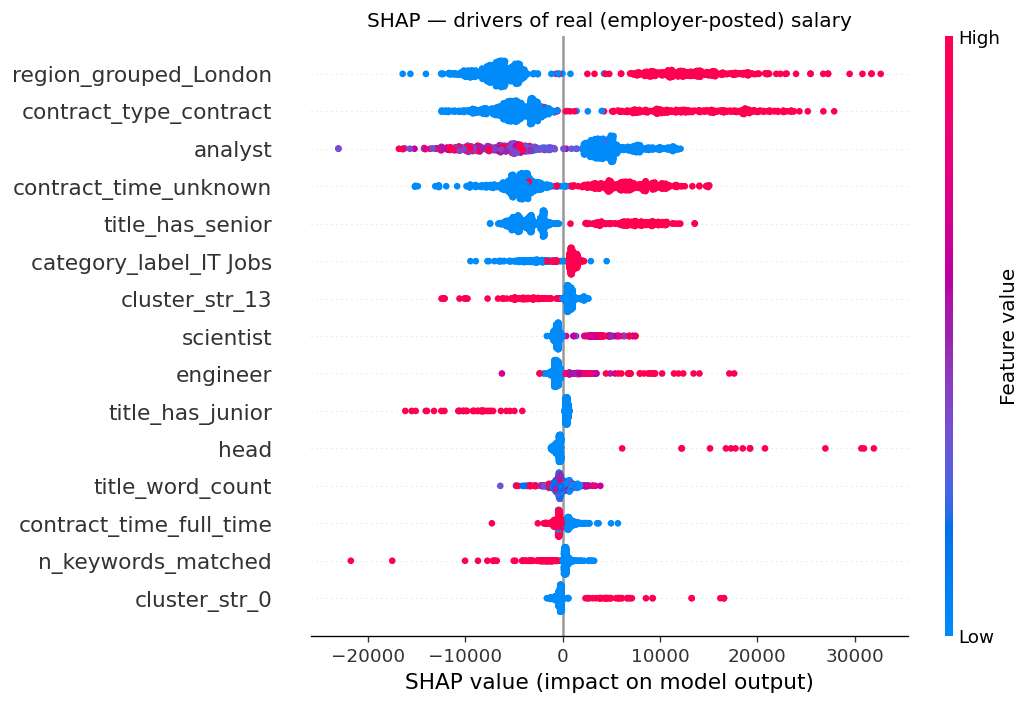

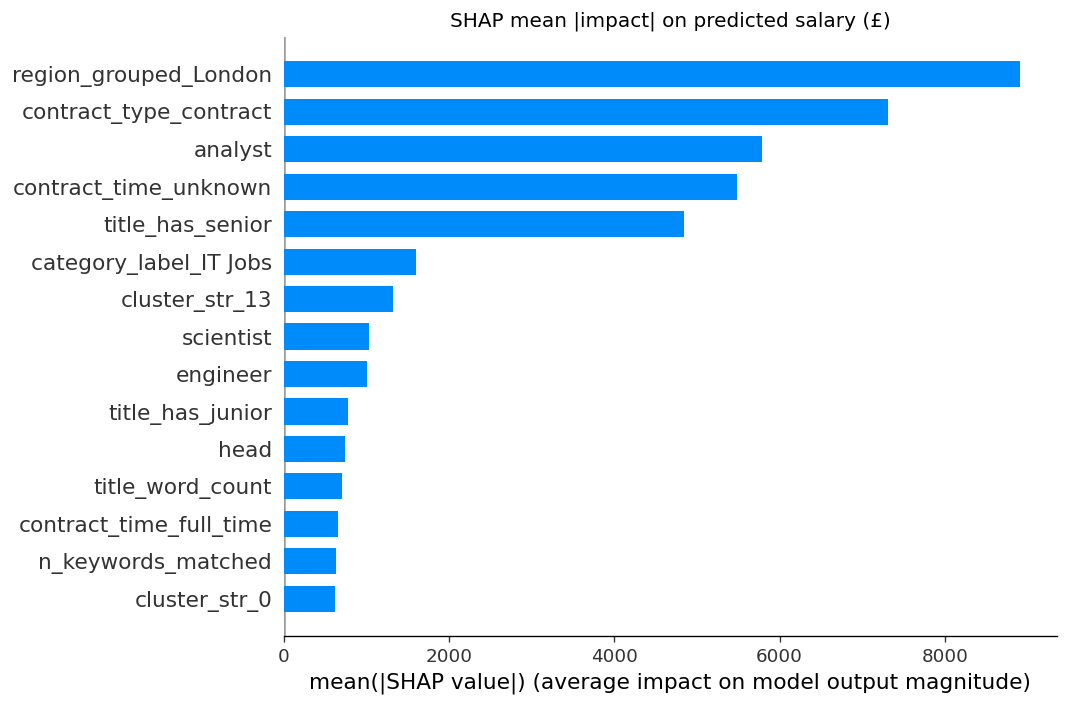

In [15]:
import shap
import xgboost as xgb_native
import matplotlib.pyplot as plt

# Fit preprocessing + model on all real-salary rows
prep_real = make_preprocessor()
X_real = prep_real.fit_transform(real[cat_features + [text_col] + num_features])
y_real = real["salary_midpoint"].values
feat_names = (list(prep_real.named_transformers_["cat"].get_feature_names_out(cat_features))
              + list(prep_real.named_transformers_["txt"].get_feature_names_out())
              + num_features)
Xd = pd.DataFrame(X_real.toarray(), columns=feat_names)

xgb_shap = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                        n_jobs=-1, random_state=42, verbosity=0).fit(Xd, y_real)

# Exact TreeSHAP via the native booster (last column is the base value)
contribs = xgb_shap.get_booster().predict(xgb_native.DMatrix(Xd), pred_contribs=True)
shap_values = contribs[:, :-1]
base_value = float(contribs[0, -1])

shap_rank = (pd.DataFrame({"feature": feat_names, "mean_abs_shap": np.abs(shap_values).mean(0)})
             .sort_values("mean_abs_shap", ascending=False))
shap_rank.to_csv("../data/processed/shap_importance_real.csv", index=False)
print(f"Model base value (mean prediction): £{base_value:,.0f}\n")
print("Top salary drivers by mean |SHAP| (average £ impact on a prediction):")
print(shap_rank.head(12).to_string(index=False))

# Beeswarm: direction + magnitude per posting
shap.summary_plot(shap_values, Xd, max_display=15, show=False, plot_size=(9, 6))
plt.title("SHAP — drivers of real (employer-posted) salary")
plt.tight_layout(); plt.savefig("../docs/shap_summary_real.png", dpi=120, bbox_inches="tight"); plt.show()

# Bar: mean |impact|
shap.summary_plot(shap_values, Xd, plot_type="bar", max_display=15, show=False, plot_size=(9, 6))
plt.title("SHAP mean |impact| on predicted salary (£)")
plt.tight_layout(); plt.savefig("../docs/shap_bar_real.png", dpi=120, bbox_inches="tight"); plt.show()

**Reading the SHAP plot.** London is the single biggest swing in real-salary predictions
(~£9K average impact — present pushes pay up, absent pushes it down), followed by contractor status
and the generic word *"analyst"* (which pulls predictions **down**). The seniority flag adds ~£5K.
This is the £-denominated, directional version of the earlier importance ranking, and it reinforces
the headline finding that **location dominates real UK data salaries** — the very signal Adzuna's own
prediction model appears to underweight.